In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Step 1: Simulate Data
np.random.seed(42)
true_beta_0 = 1
true_beta_1 = 2
N = 100
X = np.linspace(0, 1, N)
epsilon = np.random.normal(0, 1, N)
Y = true_beta_0 + true_beta_1 * X + epsilon

# Step 2: Define the Likelihood
def likelihood(y, x, beta_0, beta_1, sigma_sq):
    y_hat = beta_0 + beta_1 * x
    return stats.norm(y_hat, np.sqrt(sigma_sq)).pdf(y)

# Step 3: Define the Priors
def prior(beta_0, beta_1, sigma_sq):
    if sigma_sq <= 0:
        return 0
    else:
        return 1  # Non-informative prior

# Step 4: Metropolis-Hastings Algorithm
def metropolis_hastings(y, x, iterations, init_values):
    beta_0, beta_1, sigma_sq = init_values
    
    samples = np.zeros((iterations, 3))
    
    for i in range(iterations):
        # Propose new values for beta_0, beta_1, and sigma_sq
        beta_0_star, beta_1_star, sigma_sq_star = np.array([beta_0, beta_1, sigma_sq]) + np.random.normal(0, 0.5, 3)
        
        # Calculate the acceptance ratio
        current_likelihood = likelihood(y, x, beta_0, beta_1, sigma_sq)
        proposed_likelihood = likelihood(y, x, beta_0_star, beta_1_star, sigma_sq_star)
        current_prior = prior(beta_0, beta_1, sigma_sq)
        proposed_prior = prior(beta_0_star, beta_1_star, sigma_sq_star)
        
        # Since we have non-informative priors, they cancel out in the ratio
        r = np.prod(proposed_likelihood) / np.prod(current_likelihood)
        
        # Accept or reject the new values
        accept = np.random.rand() < r
        
        if accept:
            beta_0, beta_1, sigma_sq = beta_0_star, beta_1_star, sigma_sq_star
        
        samples[i] = [beta_0, beta_1, sigma_sq]
    
    return samples

# Run the Metropolis-Hastings Algorithm
init_values = [0, 0, 1]
iterations = 50000
samples = metropolis_hastings(Y, X, iterations, init_values)

# Burn-in and thinning
burn_in = int(iterations * 0.1)
thinned_samples = samples[burn_in::10]



/var/folders/qh/43yzjghs7pzb3lwh4m4rkxch0000gn/T/ipykernel_68094/4044561371.py:17: RuntimeWarning: invalid value encountered in sqrt
  return stats.norm(y_hat, np.sqrt(sigma_sq)).pdf(y)


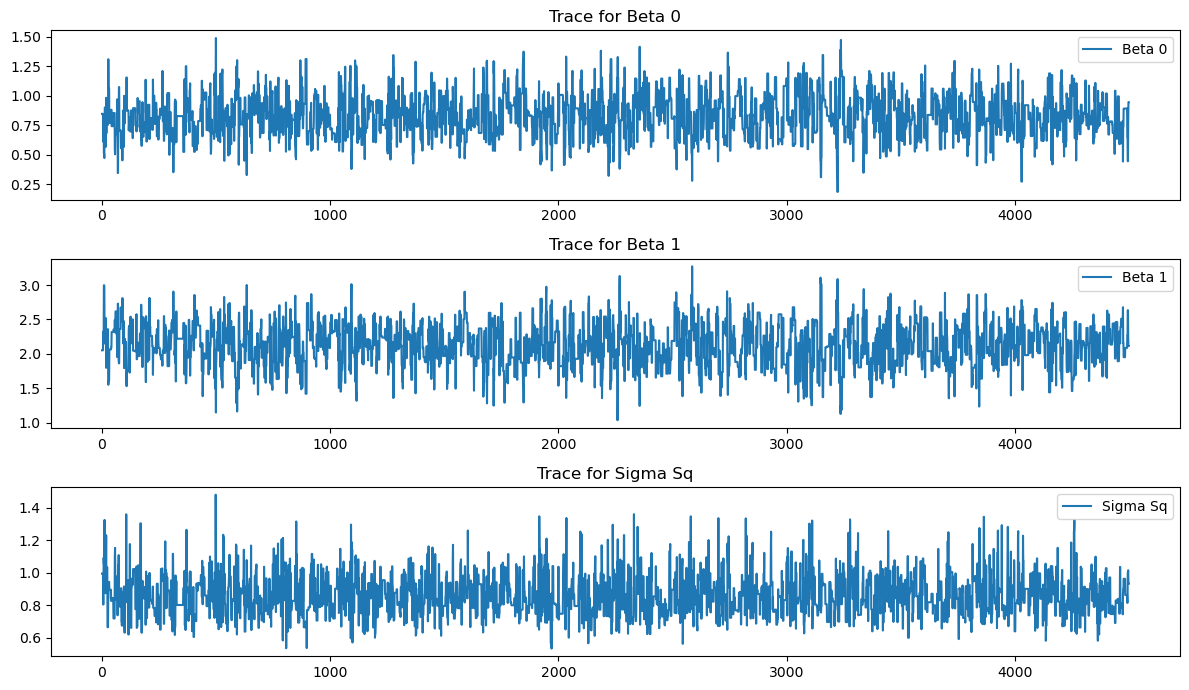

In [2]:

# Plotting the results
plt.figure(figsize=(12, 7))
plt.subplot(3,1,1)
plt.plot(thinned_samples[:,0], label='Beta 0')
plt.title('Trace for Beta 0')
plt.legend()

plt.subplot(3,1,2)
plt.plot(thinned_samples[:,1], label='Beta 1')
plt.title('Trace for Beta 1')
plt.legend()

plt.subplot(3,1,3)
plt.plot(thinned_samples[:,2], label='Sigma Sq')
plt.title('Trace for Sigma Sq')
plt.legend()

plt.tight_layout()
plt.show()



/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


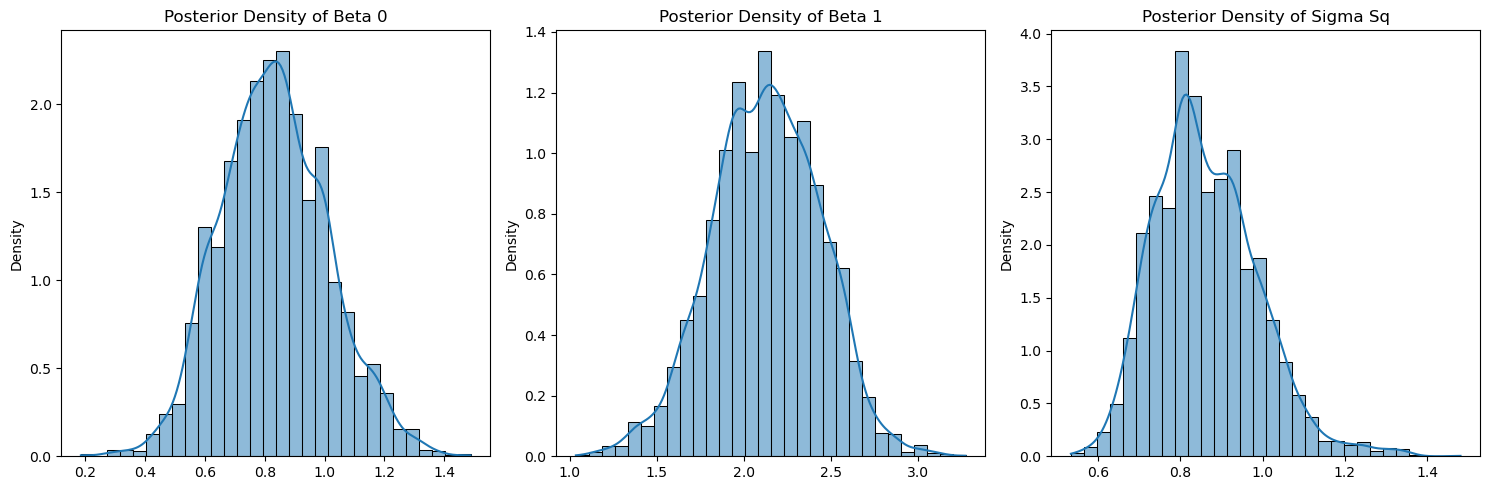

In [3]:
import seaborn as sns

# Assuming 'thinned_samples' is already obtained from the previous code
# Plotting the densities for beta_0, beta_1, and sigma_sq

plt.figure(figsize=(15, 5))

# Beta 0
plt.subplot(1, 3, 1)
sns.histplot(thinned_samples[:, 0], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Beta 0')

# Beta 1
plt.subplot(1, 3, 2)
sns.histplot(thinned_samples[:, 1], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Beta 1')

# Sigma Sq
plt.subplot(1, 3, 3)
sns.histplot(thinned_samples[:, 2], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Sigma Sq')

plt.tight_layout()
plt.show()


In [6]:
# Posterior estimates
beta_0_posterior = np.mean(thinned_samples[:, 0])
beta_1_posterior = np.mean(thinned_samples[:, 1])
sigma_sq_posterior = np.mean(thinned_samples[:, 2])

print(f"Posterior Estimate of Beta 0: {beta_0_posterior}")
print(f"Posterior Estimate of Beta 1: {beta_1_posterior}")
print(f"Posterior Estimate of Sigma Sq: {sigma_sq_posterior}")

Posterior Estimate of Beta 0: 0.8323129606861661
Posterior Estimate of Beta 1: 2.1268053899345243
Posterior Estimate of Sigma Sq: 0.8623757306471529


In [14]:
# Simulate Data with a Categorical Variable
np.random.seed(42)
true_beta_0 = 1
true_beta_1 = 2
true_beta_2 = -0.1  # Additional effect for Group B
true_beta_3=-0.1
N = 100
X = np.linspace(0, 1, N)
group = np.random.choice([0, 1], size=N)  # Group A or B
epsilon = np.random.normal(0, 1, N)
Y = true_beta_0 + true_beta_1 * X + true_beta_2 * group +true_beta_3 *X*group + epsilon

# Metropolis-Hastings Algorithm adjusted for the categorical variable
def metropolis_hastings(y, x, group, iterations, init_values):
    beta_0, beta_1, beta_2, beta_3,sigma_sq = init_values
    
    samples = np.zeros((iterations, 5))
    
    for i in range(iterations):
        # Propose new values for beta_0, beta_1, beta_2, and sigma_sq
        beta_0_star, beta_1_star, beta_2_star,beta_3_star, sigma_sq_star = np.array([beta_0, beta_1, beta_2, beta_3,sigma_sq]) + np.random.normal(0, 0.5, 5)
        
        # Calculate the acceptance ratio
        current_likelihood = likelihood(y, x, group, beta_0, beta_1, beta_2,beta_3, sigma_sq)
        proposed_likelihood = likelihood(y, x, group, beta_0_star, beta_1_star, beta_2_star,beta_3_star,sigma_sq_star)
        
        r = np.prod(proposed_likelihood) / np.prod(current_likelihood)
        
        # Accept or reject the new values
        accept = np.random.rand() < r
        
        if accept:
            beta_0, beta_1, beta_2, beta_3,sigma_sq = beta_0_star, beta_1_star, beta_2_star, beta_3_star,sigma_sq_star
        
        samples[i] = [beta_0, beta_1, beta_2,beta_3,sigma_sq]
    
    return samples

# Adjust the likelihood function to include the group
def likelihood(y, x, group, beta_0, beta_1, beta_2,beta_3 ,sigma_sq):
    y_hat = beta_0 + beta_1 * x + beta_2 * group+beta_3*x*group
    return stats.norm(y_hat, np.sqrt(sigma_sq)).pdf(y)

# Run the Metropolis-Hastings Algorithm with the initial values including beta_2
init_values = [0, 0, 0,0, 1]
iterations = 50000
samples = metropolis_hastings(Y, X, group, iterations, init_values)



/var/folders/tp/k5dxnl995j9b35c8rl_p_rgm0000gn/T/ipykernel_18829/162408599.py:42: RuntimeWarning: invalid value encountered in sqrt
  return stats.norm(y_hat, np.sqrt(sigma_sq)).pdf(y)


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

Text(0.5, 1.0, 'Posterior Density of Beta 3 ')

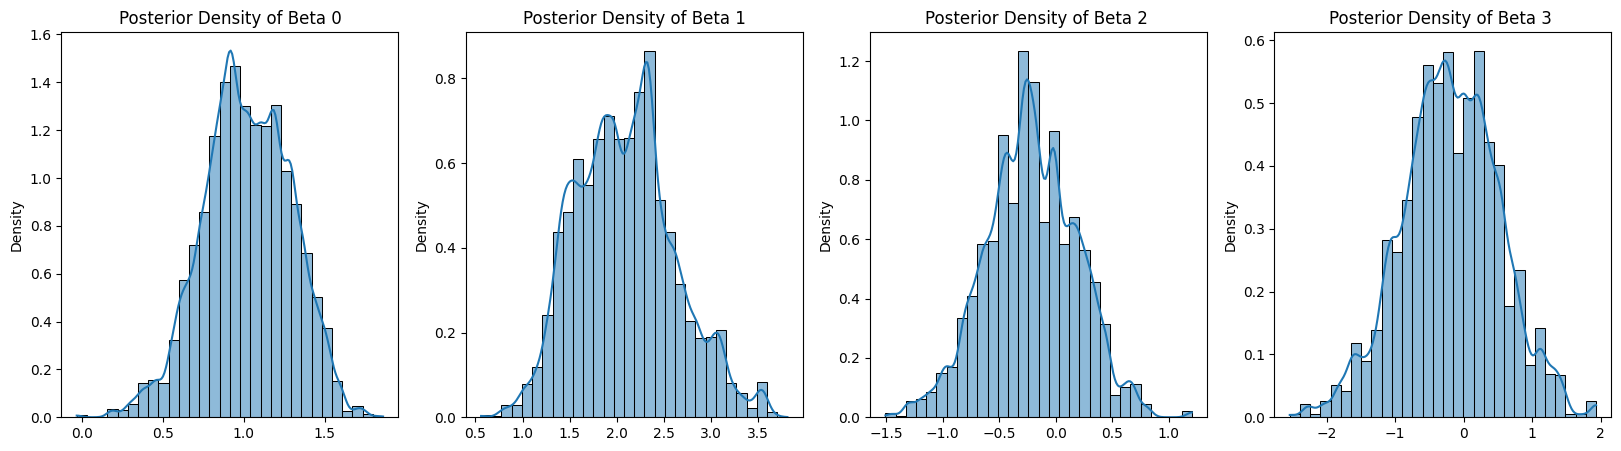

In [15]:
# Plotting the densities using the same method as before
# Assume 'samples' has been appropriately thinned and burned-in as needed

plt.figure(figsize=(20, 5))

# Beta 0
plt.subplot(1, 4, 1)
sns.histplot(samples[:, 0], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Beta 0')

# Beta 1
plt.subplot(1, 4, 2)
sns.histplot(samples[:, 1], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Beta 1')

# Beta 2 (for the categorical variable)
plt.subplot(1, 4, 3)
sns.histplot(samples[:, 2], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Beta 2 ')

# Beta 3 (for the categorical variable)
plt.subplot(1, 4, 4)
sns.histplot(samples[:, 3], kde=True, stat='density', bins=30)
plt.title('Posterior Density of Beta 3 ')


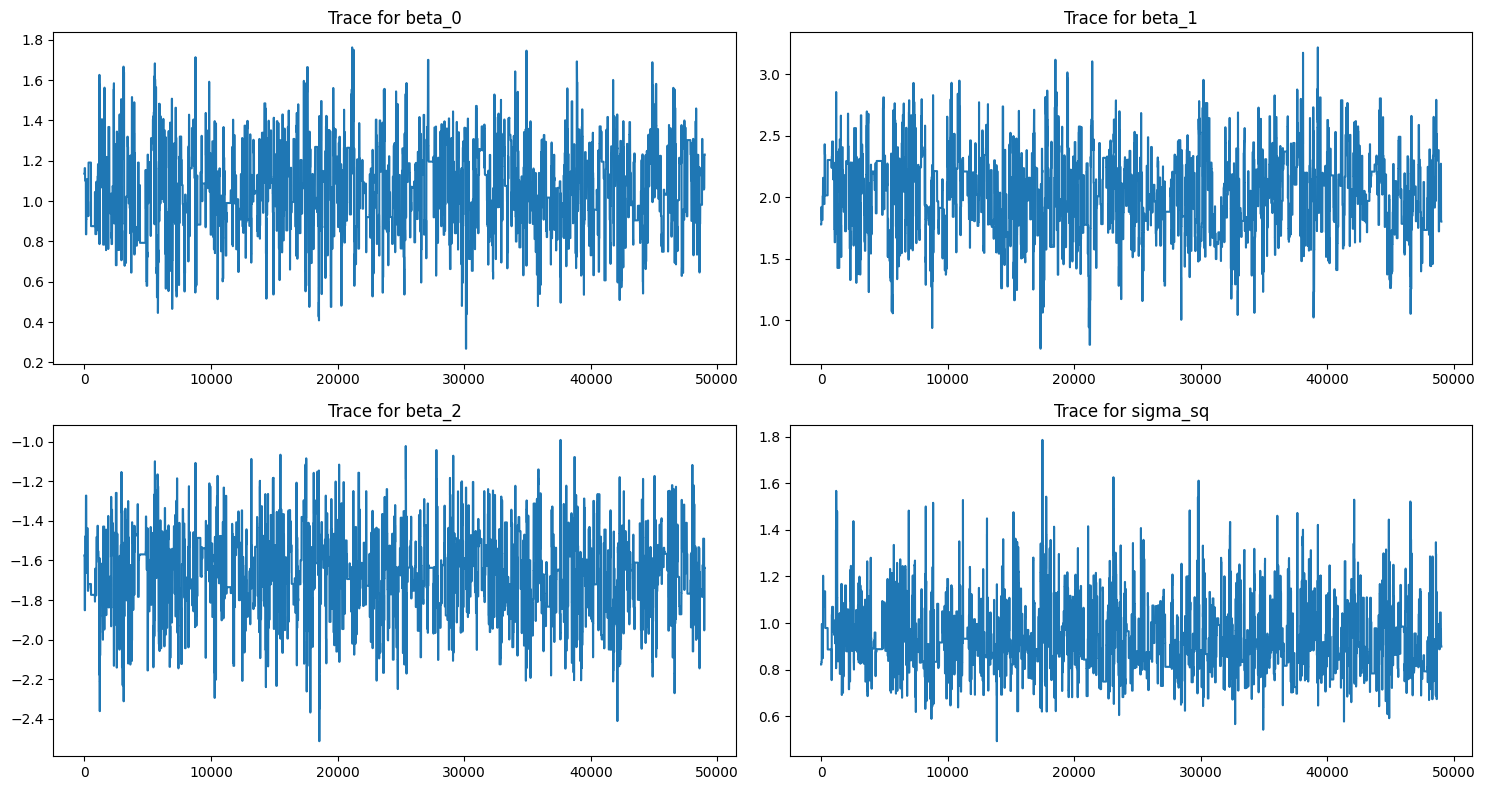

In [9]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

true_beta_2 = -1.5  # Additional effect for Group B


def plot_traces(samples, burn_in=1000):
    # Assuming the first few samples are burn-in
    samples = samples[burn_in:]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 8))
    for i, param in enumerate(['beta_0', 'beta_1', 'beta_2', 'sigma_sq']):
        ax = axes[i//2, i%2]
        ax.plot(samples[:, i])
        ax.set_title(f'Trace for {param}')
    plt.tight_layout()
    plt.show()

plot_traces(samples)



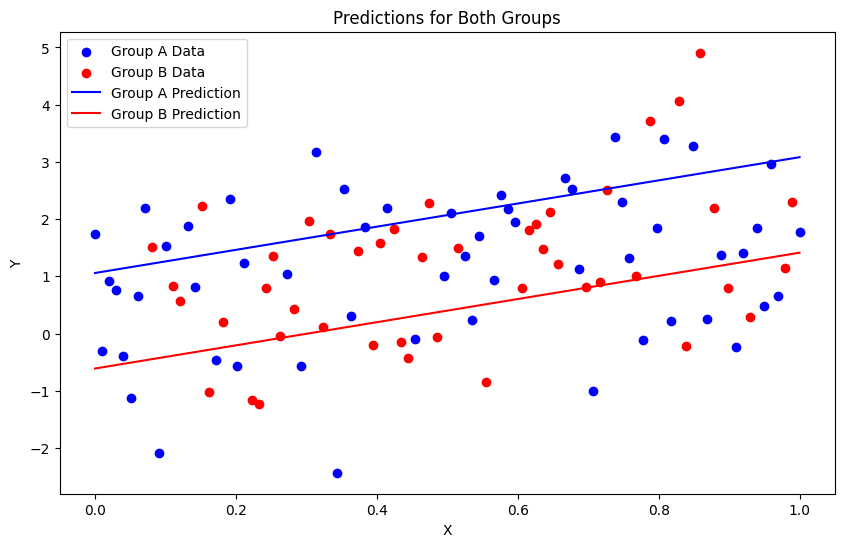

In [10]:
groups = np.random.choice([0, 1], size=N)  # 0 for Group A, 1 for Group B
def predict(x, groups, samples):
    # Use the mean of the posterior samples for predictions
    beta_0_mean = np.mean(samples[:, 0])
    beta_1_mean = np.mean(samples[:, 1])
    beta_2_mean = np.mean(samples[:, 2])
    
    return beta_0_mean + beta_1_mean * x + beta_2_mean * groups

# Use the model to predict for both groups
X_pred = np.linspace(0, 1, 100)
predictions_group_A = predict(X_pred, np.zeros_like(X_pred), samples)
predictions_group_B = predict(X_pred, np.ones_like(X_pred), samples)

# Plot the predictions
plt.figure(figsize=(10, 6))
plt.scatter(X[groups == 0], Y[groups == 0], color='blue', label='Group A Data')
plt.scatter(X[groups == 1], Y[groups == 1], color='red', label='Group B Data')
plt.plot(X_pred, predictions_group_A, color='blue', label='Group A Prediction')
plt.plot(X_pred, predictions_group_B, color='red', label='Group B Prediction')
plt.title('Predictions for Both Groups')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()


In [16]:
import numpy as np
import scipy.stats as stats

np.random.seed(42)

# True parameter values
true_beta_0 = -1
true_beta_1 = 2.5
true_beta_2 = 1.5  # Effect for Group B

# Number of observations
N = 100

# Simulate continuous predictor variable
X = np.linspace(0, 1, N)

# Simulate categorical predictor variable
group = np.random.choice([0, 1], size=N)

# Calculate probability of Y=1
prob_Y = 1 / (1 + np.exp(-(true_beta_0 + true_beta_1 * X + true_beta_2 * group)))

# Simulate binary outcome variable
Y = np.random.binomial(1, prob_Y)


In [21]:
def logistic_likelihood(y, x, group, beta_0, beta_1, beta_2):
    logits = beta_0 + beta_1 * x + beta_2 * group
    prob_1 = 1 / (1 + np.exp(-logits))
    return np.where(y == 1, prob_1, 1 - prob_1)


In [18]:
def metropolis_hastings_logistic(y, x, group, iterations, init_values):
    beta_0, beta_1, beta_2 = init_values
    n_params = len(init_values)
    samples = np.zeros((iterations, n_params))
    current_log_prob = np.sum(np.log(logistic_likelihood(y, x, group, beta_0, beta_1, beta_2)))

    for i in range(iterations):
        # Propose new candidate from the normal distribution
        beta_0_star, beta_1_star, beta_2_star = np.array([beta_0, beta_1, beta_2]) + np.random.normal(0, 0.5, n_params)
        candidate_log_prob = np.sum(np.log(logistic_likelihood(y, x, group, beta_0_star, beta_1_star, beta_2_star)))
        
        # Acceptance probability
        acceptance_prob = min(1, np.exp(candidate_log_prob - current_log_prob))
        
        # Accept or reject the candidate
        if np.random.rand() < acceptance_prob:
            beta_0, beta_1, beta_2 = beta_0_star, beta_1_star, beta_2_star
            current_log_prob = candidate_log_prob
        
        samples[i] = [beta_0, beta_1, beta_2]
    
    return samples

# Initial parameter values
init_values = [0, 0, 0]

# Number of iterations
iterations = 50000

# Run Metropolis-Hastings algorithm
samples = metropolis_hastings_logistic(Y, X, group, iterations, init_values)


In [22]:
import numpy as np
import scipy.stats as stats

# Seed for reproducibility
np.random.seed(42)

# Number of observations and parameters
n_obs = 100
n_params = 4

# Simulate independent variables
X = np.random.normal(0, 1, (n_obs, n_params))

# True betas for simulation (we can choose diverse true values)
true_betas = np.array([0.5, -1, 1.5, 2])

# Simulate noise
noise = np.random.normal(0, 2, n_obs)

# Define a logistic function
def logistic(x):
    return 1 / (1 + np.exp(-x))

# Simulate dependent variable (Bernoulli outcomes)
probabilities = logistic(np.dot(X, true_betas) + noise)
y = np.random.binomial(1, probabilities)


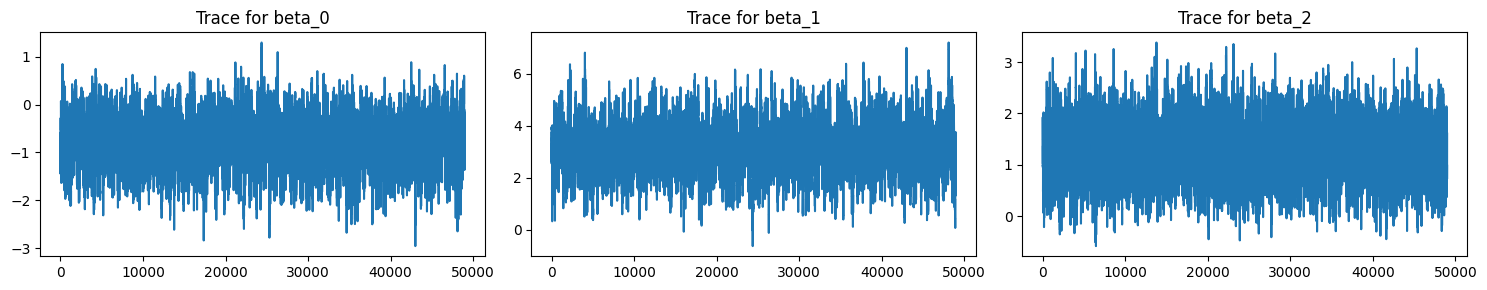

In [20]:
import matplotlib.pyplot as plt

def plot_traces(samples, param_names=['beta_0', 'beta_1', 'beta_2'], burn_in=1000):
    samples = samples[burn_in:]
    fig, axes = plt.subplots(1, len(param_names), figsize=(15, 3))
    for i, name in enumerate(param_names):
        ax = axes[i]
        ax.plot(samples[:, i])
        ax.set_title(f'Trace for {name}')
    plt.tight_layout()
    plt.show()

plot_traces(samples)


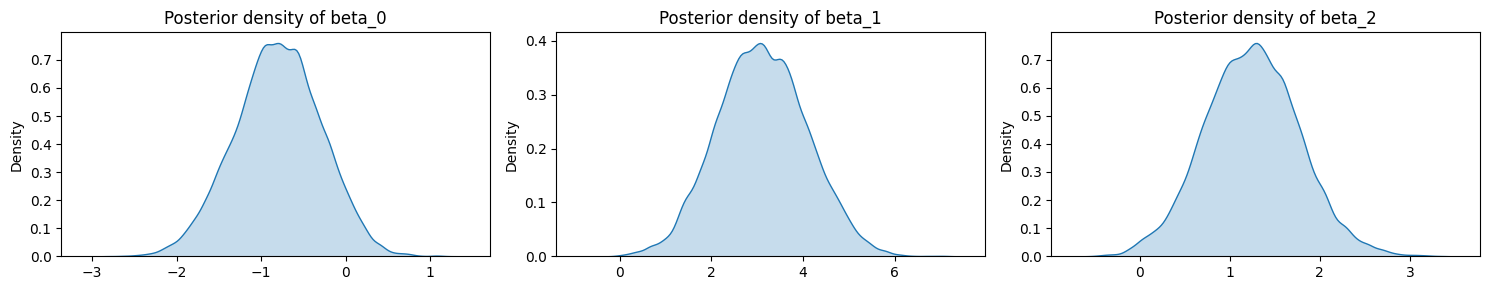

In [20]:
import seaborn as sns

def plot_posterior_densities(samples, param_names=['beta_0', 'beta_1', 'beta_2'], burn_in=1000):
    samples = samples[burn_in:]
    fig, axes = plt.subplots(1, len(param_names), figsize=(15, 3))
    for i, name in enumerate(param_names):
        ax = axes[i]
        sns.kdeplot(samples[:, i], ax=ax, fill=True)
        ax.set_title(f'Posterior density of {name}')
    plt.tight_layout()
    plt.show()

plot_posterior_densities(samples)


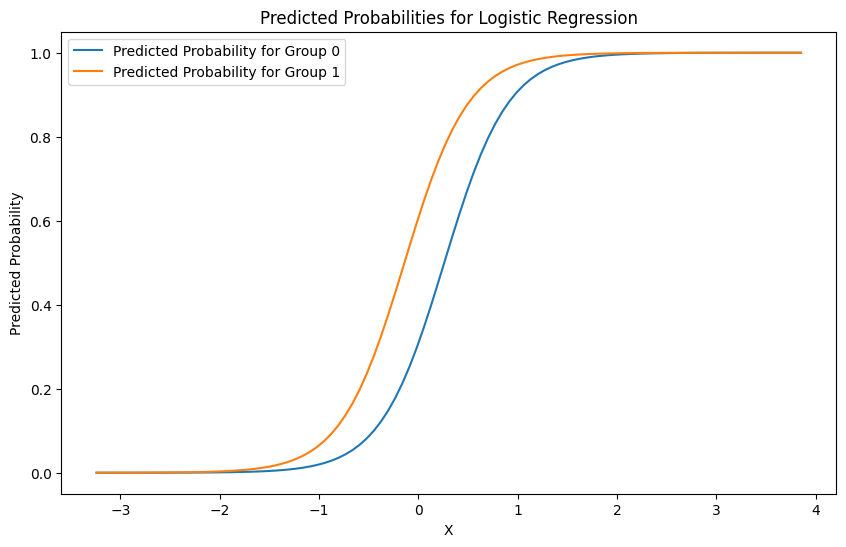

In [22]:
# Calculate the posterior means after burn-in
burn_in = 1000
beta_0_mean = np.mean(samples[burn_in:, 0])
beta_1_mean = np.mean(samples[burn_in:, 1])
beta_2_mean = np.mean(samples[burn_in:, 2])

# Calculate predicted probabilities
def predict_proba(x, group, beta_0, beta_1, beta_2):
    logits = beta_0 + beta_1 * x + beta_2 * group
    return 1 / (1 + np.exp(-logits))

# Generate a range of values for X
x_range = np.linspace(X.min(), X.max(), 100)

# Predict probabilities for each group
prob_group_0 = predict_proba(x_range, 0, beta_0_mean, beta_1_mean, beta_2_mean)
prob_group_1 = predict_proba(x_range, 1, beta_0_mean, beta_1_mean, beta_2_mean)

# Plot the predicted probabilities
plt.figure(figsize=(10, 6))
plt.plot(x_range, prob_group_0, label='Predicted Probability for Group 0')
plt.plot(x_range, prob_group_1, label='Predicted Probability for Group 1')



plt.xlabel('X')
plt.ylabel('Predicted Probability')
plt.title('Predicted Probabilities for Logistic Regression')
plt.legend()
plt.show()


In [23]:
# Prior distributions for the betas
# For example, normal priors with different means and standard deviations
beta_priors = [stats.norm(loc=0, scale=1),  # Prior for beta_1
               stats.norm(loc=0, scale=2),  # Prior for beta_2
               stats.norm(loc=0, scale=3),  # Prior for beta_3
               stats.norm(loc=0, scale=4)]  # Prior for beta_4

# Likelihood function for logistic regression
def likelihood(beta, X, y):
    prob = logistic(X @ beta)
    return np.prod(prob**y * (1 - prob)**(1 - y))


In [24]:
def metropolis_hastings(likelihood, priors, initial_beta, iterations, data):
    n_params = len(priors)
    # Store the samples
    samples = np.zeros((iterations, n_params))
    # Start from the initial beta
    beta_current = initial_beta
    # Compute the current likelihood
    likelihood_current = likelihood(beta_current, *data)

    # Sampling process
    for i in range(iterations):
        # Propose new candidate from the prior
        beta_proposal = np.array([priors[j].rvs() for j in range(n_params)])
        # Compute likelihood of proposed candidate
        likelihood_proposal = likelihood(beta_proposal, *data)

        # Compute prior probabilities for current and proposed betas
        prior_current = np.prod([priors[j].pdf(beta_current[j]) for j in range(n_params)])
        prior_proposal = np.prod([priors[j].pdf(beta_proposal[j]) for j in range(n_params)])

        # Calculate acceptance probability
        p_accept = (likelihood_proposal * prior_proposal) / (likelihood_current * prior_current)

        # Accept proposal?
        accept = np.random.rand() < p_accept

        # Update position
        if accept:
            beta_current = beta_proposal
            likelihood_current = likelihood_proposal

        samples[i] = beta_current

    return samples

# Initial guess for betas
initial_beta = np.zeros(n_params)

# Number of iterations
iterations = 100000

# Perform Metropolis-Hastings sampling
samples = metropolis_hastings(likelihood, beta_priors, initial_beta, iterations, data=(X, y))

# Burn-in and thinning if needed
burn_in = int(iterations * 0.1)
thinned_samples = samples[burn_in::10]


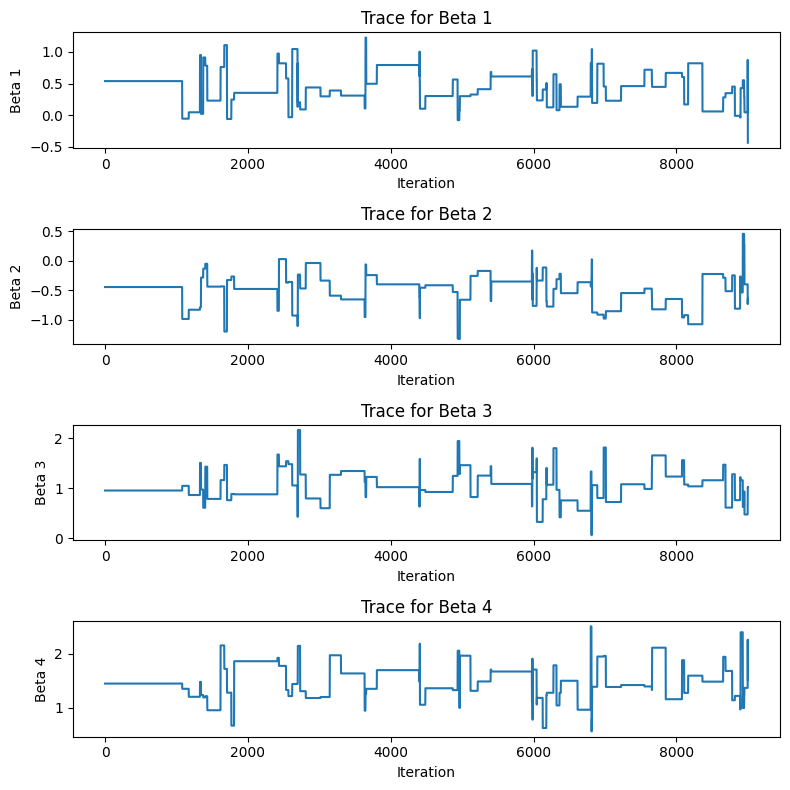

In [25]:
import matplotlib.pyplot as plt

# Plot the trace for each parameter
fig, axes = plt.subplots(n_params, 1, figsize=(8, 8))
for i in range(n_params):
    axes[i].plot(thinned_samples[:, i])
    axes[i].set_title(f'Trace for Beta {i+1}')
    axes[i].set_xlabel('Iteration')
    axes[i].set_ylabel(f'Beta {i+1}')
plt.tight_layout()
plt.show()



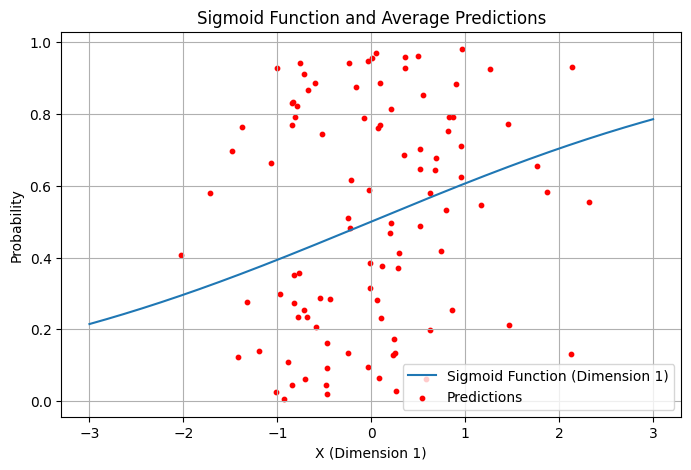

In [26]:
# Compute average beta from the posterior samples
average_beta = np.mean(thinned_samples, axis=0)

# Function to compute logistic regression predictions
def logistic_regression_predictions(X, beta):
    linear_combination = np.dot(X, beta)
    return logistic(linear_combination)

# Compute predictions with average beta
average_predictions = logistic_regression_predictions(X, average_beta)

# Let's visualize the sigmoid function over a range of linear predictor values
# Since we have multiple variables, we'll just visualize one dimension at a time
x_range = np.linspace(-3, 3, 300)

# Choose one dimension to illustrate
dim_to_plot = 0

# Compute the sigmoid function over the range of values for the chosen dimension
sigmoid_values = logistic(x_range * average_beta[dim_to_plot])

# Plot the sigmoid function
plt.figure(figsize=(8, 5))
plt.plot(x_range, sigmoid_values, label=f'Sigmoid Function (Dimension {dim_to_plot+1})')
plt.scatter(X[:, dim_to_plot], average_predictions, color='red', s=10, label='Predictions')
plt.title('Sigmoid Function and Average Predictions')
plt.xlabel(f'X (Dimension {dim_to_plot+1})')
plt.ylabel('Probability')
plt.legend()
plt.grid(True)
plt.show()


/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/homebrew/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

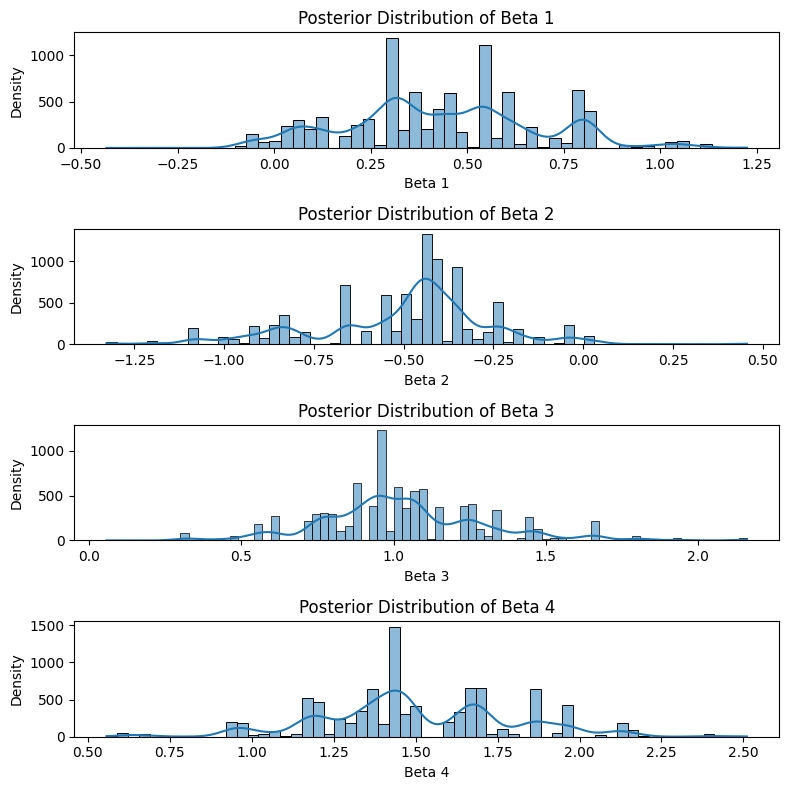

In [27]:
import seaborn as sns

# Plot the distributions for each beta
fig, axes = plt.subplots(n_params, 1, figsize=(8, 2 * n_params))

for i in range(n_params):
    sns.histplot(thinned_samples[:, i], kde=True, ax=axes[i])
    axes[i].set_title(f'Posterior Distribution of Beta {i+1}')
    axes[i].set_xlabel(f'Beta {i+1}')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()
